<a href="https://colab.research.google.com/github/namii07/Namisha-Codeboosters-Internship-2026/blob/main/Phase_01_Data_Engineering/Phase_01_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

from pyspark.sql import SparkSession

In [ ]:
df=pd.read_csv("large_sales_data.csv")

print(df.head())
print(df.shape)
print(df.info())

   order_id customer_name     product     category  quantity  unit_price  \
0      1001   Sneha Reddy     Monitor  Electronics        12       22000   
1      1002  Ramesh Kumar     Printer  Electronics        10       12000   
2      1003  Rahul Mishra       Mouse  Accessories        10         800   
3      1004    Suresh Rao      Tablet  Electronics         5       32000   
4      1005   Priya Patel  Headphones  Electronics         4        3500   

   revenue  order_date       city region    sales_rep    payment_method  \
0   264000  2023-05-21     Mumbai   West  Meera Patel               UPI   
1   120000  2023-08-05      Delhi  North  Anil Sharma       Credit Card   
2     8000  2023-01-14  Ahmedabad   West  Meera Patel  Cash on Delivery   
3   160000  2023-01-04      Surat   West   Ravi Kumar  Cash on Delivery   
4    14000  2023-06-22  Bangalore  South   Sunita Rao  Cash on Delivery   

  order_status  
0    Delivered  
1      Shipped  
2      Shipped  
3   Processing  
4    De

In [ ]:
print("Shape:",df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Shape: (5000, 13)

Columns:
Index(['order_id', 'customer_name', 'product', 'category', 'quantity',
       'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep',
       'payment_method', 'order_status'],
      dtype='object')

Data Types:
order_id           int64
customer_name     object
product           object
category          object
quantity           int64
unit_price         int64
revenue            int64
order_date        object
city              object
region            object
sales_rep         object
payment_method    object
order_status      object
dtype: object

Missing Values:
order_id          0
customer_name     0
product           0
category          0
quantity          0
unit_price        0
revenue           0
order_date        0
city              0
region            0
sales_rep         0
payment_method    0
order_status      0
dtype: int64

Duplicates:
0


In [ ]:
df=df.drop_duplicates()

df["order_date"]=pd.to_datetime(df["order_date"])

df["quantity"]=df["quantity"].astype(int)

df["unit_price"]=df["unit_price"].astype(float)

df["revenue"]=df["revenue"].astype(float)

df.columns=df.columns.str.lower().str.replace(" ","_")

df=df.fillna({
"city":"Unknown",
"region":"Unknown",
"sales_rep":"Unknown"
})

df.to_csv("cleaned_sales.csv",index=False)

df.head()

,order_id,customer_name,product,category,quantity,unit_price,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1001,Sneha Reddy,Monitor,Electronics,12,22000.0,264000.0,2023-05-21,Mumbai,West,Meera Patel,UPI,Delivered
1,1002,Ramesh Kumar,Printer,Electronics,10,12000.0,120000.0,2023-08-05,Delhi,North,Anil Sharma,Credit Card,Shipped
2,1003,Rahul Mishra,Mouse,Accessories,10,800.0,8000.0,2023-01-14,Ahmedabad,West,Meera Patel,Cash on Delivery,Shipped
3,1004,Suresh Rao,Tablet,Electronics,5,32000.0,160000.0,2023-01-04,Surat,West,Ravi Kumar,Cash on Delivery,Processing
4,1005,Priya Patel,Headphones,Electronics,4,3500.0,14000.0,2023-06-22,Bangalore,South,Sunita Rao,Cash on Delivery,Delivered


In [ ]:
conn=sqlite3.connect("sales.db")

df.to_sql("sales_table",conn,if_exists="replace",index=False)

cursor=conn.cursor()

cursor.execute("SELECT COUNT(*) FROM sales_table")

print(cursor.fetchone())

(5000,)


In [ ]:
pd.read_sql("""
SELECT * FROM sales_table
WHERE revenue>100000
""",conn)

,order_id,customer_name,product,category,quantity,unit_price,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1001,Sneha Reddy,Monitor,Electronics,12,22000.0,264000.0,2023-05-21 00:00:00,Mumbai,West,Meera Patel,UPI,Delivered
1,1002,Ramesh Kumar,Printer,Electronics,10,12000.0,120000.0,2023-08-05 00:00:00,Delhi,North,Anil Sharma,Credit Card,Shipped
2,1004,Suresh Rao,Tablet,Electronics,5,32000.0,160000.0,2023-01-04 00:00:00,Surat,West,Ravi Kumar,Cash on Delivery,Processing
3,1008,Priya Patel,Laptop,Electronics,13,45000.0,585000.0,2023-05-29 00:00:00,Chennai,South,Meera Patel,Credit Card,Cancelled
4,1019,Kavya Nambiar,Printer,Electronics,9,12000.0,108000.0,2023-02-24 00:00:00,Bangalore,South,Deepak Joshi,UPI,Shipped
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1410,5976,Ananya Das,Tablet,Electronics,10,32000.0,320000.0,2023-02-15 00:00:00,Delhi,North,Suresh Iyer,UPI,Shipped
1411,5984,Arjun Nair,Laptop,Electronics,10,45000.0,450000.0,2023-11-30 00:00:00,Chennai,South,Kavya Reddy,Net Banking,Delivered
1412,5986,Tanvi Mehta,Tablet,Electronics,4,32000.0,128000.0,2023-02-07 00:00:00,Hyderabad,South,Ravi Kumar,Net Banking,Shipped
1413,5990,Tanvi Mehta,Tablet,Electronics,7,32000.0,224000.0,2023-04-06 00:00:00,Kolkata,East,Deepak Joshi,UPI,Shipped


In [ ]:
pd.read_sql("""
SELECT * FROM sales_table
ORDER BY revenue DESC
LIMIT 10
""",conn)

,order_id,customer_name,product,category,quantity,unit_price,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1021,Tanvi Mehta,Laptop,Electronics,15,45000.0,675000.0,2023-07-05 00:00:00,Delhi,North,Deepak Joshi,UPI,Delivered
1,1456,Sneha Reddy,Laptop,Electronics,15,45000.0,675000.0,2023-11-11 00:00:00,Kolkata,East,Ravi Kumar,Net Banking,Shipped
2,1525,Arjun Nair,Laptop,Electronics,15,45000.0,675000.0,2023-11-24 00:00:00,Pune,West,Anil Sharma,Credit Card,Delivered
3,1572,Ananya Das,Laptop,Electronics,15,45000.0,675000.0,2023-06-15 00:00:00,Bangalore,South,Anil Sharma,Net Banking,Cancelled
4,1802,Ramesh Kumar,Laptop,Electronics,15,45000.0,675000.0,2023-12-12 00:00:00,Jaipur,North,Sunita Rao,Cash on Delivery,Delivered
5,1971,Kiran Kumar,Laptop,Electronics,15,45000.0,675000.0,2023-03-02 00:00:00,Pune,West,Kavya Reddy,Net Banking,Cancelled
6,2022,Divya Singh,Laptop,Electronics,15,45000.0,675000.0,2023-05-01 00:00:00,Kolkata,East,Priya Nair,Credit Card,Delivered
7,2089,Ananya Das,Laptop,Electronics,15,45000.0,675000.0,2023-10-04 00:00:00,Mumbai,West,Deepak Joshi,UPI,Processing
8,2124,Arjun Nair,Laptop,Electronics,15,45000.0,675000.0,2023-09-04 00:00:00,Mumbai,West,Deepak Joshi,Cash on Delivery,Processing
9,2223,Kiran Kumar,Laptop,Electronics,15,45000.0,675000.0,2023-04-22 00:00:00,Delhi,North,Deepak Joshi,Cash on Delivery,Delivered


In [ ]:
pd.read_sql("""
SELECT SUM(revenue) AS total_sales
FROM sales_table
""",conn)

,total_sales
0,495847600.0


In [ ]:
pd.read_sql("""
SELECT category,
SUM(revenue) total
FROM sales_table
GROUP BY category
""",conn)

,category,total
0,Accessories,21515100.0
1,Electronics,474332500.0


In [ ]:
pd.read_sql("""
SELECT order_id,
CASE
WHEN revenue>100000 THEN 'High'
ELSE 'Low'
END AS sales_type
FROM sales_table
""",conn)

,order_id,sales_type
0,1001,High
1,1002,High
2,1003,Low
3,1004,High
4,1005,Low
...,...,...
4995,5996,Low
4996,5997,Low
4997,5998,Low
4998,5999,High


In [ ]:
query="""
SELECT *,
quantity*unit_price AS calculated_revenue,

CASE
WHEN revenue>200000 THEN 'Premium'
WHEN revenue>50000 THEN 'Medium'
ELSE 'Basic'
END AS customer_segment

FROM sales_table
"""

transformed=pd.read_sql(query,conn)

transformed.to_csv(
"transformed_sales.csv",
index=False
)

transformed.head()

,order_id,customer_name,product,category,quantity,unit_price,revenue,order_date,city,region,sales_rep,payment_method,order_status,calculated_revenue,customer_segment
0,1001,Sneha Reddy,Monitor,Electronics,12,22000.0,264000.0,2023-05-21 00:00:00,Mumbai,West,Meera Patel,UPI,Delivered,264000.0,Premium
1,1002,Ramesh Kumar,Printer,Electronics,10,12000.0,120000.0,2023-08-05 00:00:00,Delhi,North,Anil Sharma,Credit Card,Shipped,120000.0,Medium
2,1003,Rahul Mishra,Mouse,Accessories,10,800.0,8000.0,2023-01-14 00:00:00,Ahmedabad,West,Meera Patel,Cash on Delivery,Shipped,8000.0,Basic
3,1004,Suresh Rao,Tablet,Electronics,5,32000.0,160000.0,2023-01-04 00:00:00,Surat,West,Ravi Kumar,Cash on Delivery,Processing,160000.0,Medium
4,1005,Priya Patel,Headphones,Electronics,4,3500.0,14000.0,2023-06-22 00:00:00,Bangalore,South,Sunita Rao,Cash on Delivery,Delivered,14000.0,Basic


In [ ]:
def extract(file):
    return pd.read_csv(file)

def transform(data):

    data=data.drop_duplicates()

    data["order_date"]=pd.to_datetime(
        data["order_date"]
    )

    data=data.fillna("Unknown")

    return data

def load(data,out):

    data.to_csv(out,index=False)

raw=extract("large_sales_data.csv")

clean=transform(raw)

load(clean,"etl_output.csv")

print("ETL Completed")

ETL Completed


In [ ]:
spark=SparkSession.builder.appName(
"Medallion"
).getOrCreate()

bronze=spark.read.csv(
"large_sales_data.csv",
header=True,
inferSchema=True
)

bronze.write.mode(
"overwrite"
).parquet(
"bronze_layer"
)

In [ ]:
silver=bronze.dropDuplicates()

silver=silver.na.drop()

silver.write.mode(
"overwrite"
).parquet(
"silver_layer"
)

In [ ]:
gold=silver.groupBy(
"category"
).sum(
"revenue"
)

gold.write.mode(
"overwrite"
).parquet(
"gold_layer"
)

gold.show()

+-----------+------------+
|   category|sum(revenue)|
+-----------+------------+
|Electronics|   474332500|
|Accessories|    21515100|
+-----------+------------+



In [ ]:
comparison=pd.DataFrame({
"Dimension":[
"File Size",
"Storage",
"Read Write",
"Advantages",
"Limitations"
],

"CSV":[
"Larger",
"Low",
"Slower",
"Easy",
"No schema"
],

"Parquet":[
"Smaller",
"High",
"Faster",
"Efficient",
"Less human readable"
]
})

comparison

,Dimension,CSV,Parquet
0,File Size,Larger,Smaller
1,Storage,Low,High
2,Read Write,Slower,Faster
3,Advantages,Easy,Efficient
4,Limitations,No schema,Less human readable


In [ ]:
spark_df=spark.read.parquet(
"gold_layer"
)

pandas_df=spark_df.toPandas()

print(pandas_df.head())

      category  sum(revenue)
0  Electronics     474332500
1  Accessories      21515100


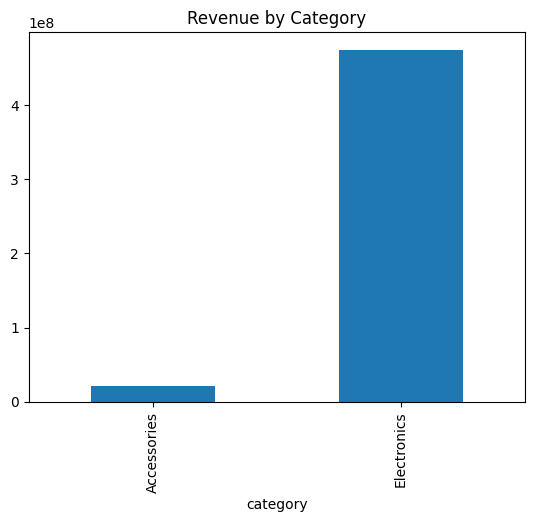

In [ ]:
category=df.groupby(
"category"
)["revenue"].sum()

category.plot.bar()

plt.title(
"Revenue by Category"
)

plt.show()

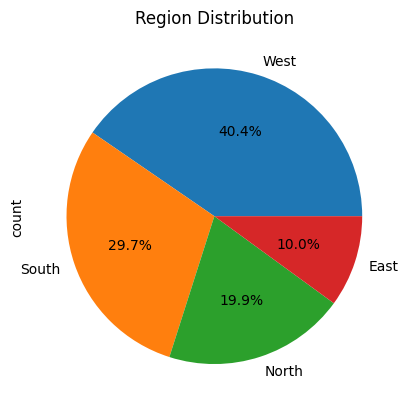

In [ ]:
region=df["region"].value_counts()

region.plot.pie(
autopct="%1.1f%%"
)

plt.title(
"Region Distribution"
)

plt.show()

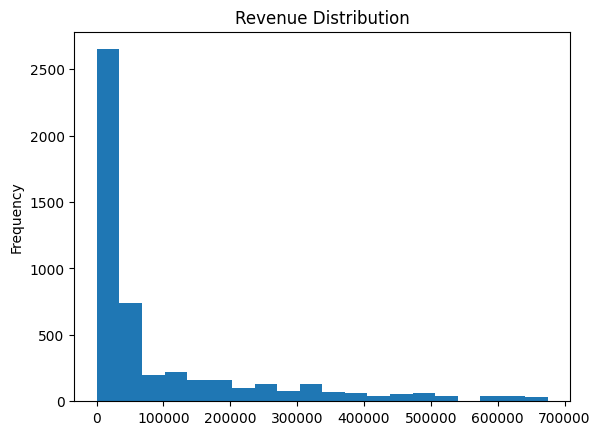

In [ ]:
df["revenue"].plot.hist(
bins=20
)

plt.title(
"Revenue Distribution"
)

plt.show()

In [ ]:
features=df[
[
"quantity",
"unit_price"
]
]

target=df["revenue"]

x_train,x_test,y_train,y_test=(
train_test_split(
features,
target,
test_size=0.2,
random_state=42
)
)

model=LinearRegression()

model.fit(
x_train,
y_train
)

pred=model.predict(
x_test
)

print(
"MAE:",
mean_absolute_error(
y_test,
pred
)
)

print(
"R2:",
r2_score(
y_test,
pred
)
)

MAE: 46388.41632792213
R2: 0.7962334062207533
